# Bank Loan Risk Analysis - Python EDA

In [17]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv(r"C:\Users\soumy\Downloads\loan_data.csv")

In [6]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [8]:
df.shape

(45000, 14)

In [9]:
df.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [11]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [7]:
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [12]:
df.duplicated().sum()

0

In [13]:
df['person_gender'].unique()

array(['female', 'male'], dtype=object)

In [14]:
df['person_education'].unique()

array(['Master', 'High School', 'Bachelor', 'Associate', 'Doctorate'],
      dtype=object)

In [15]:
df['loan_intent'].unique()

array(['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT',
       'DEBTCONSOLIDATION'], dtype=object)

In [16]:
df['loan_status'].unique()

array([1, 0], dtype=int64)

## Exploratory Data Analysis

### Loan Status Analysis

In [18]:
df['loan_status'].value_counts()

loan_status
0    35000
1    10000
Name: count, dtype: int64

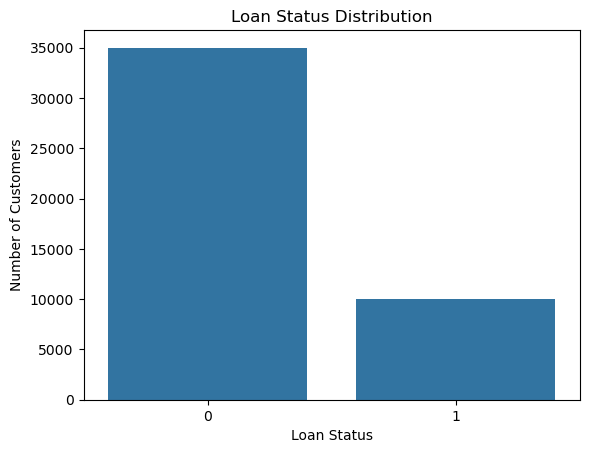

In [19]:
sns.countplot(x='loan_status', data=df)
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Number of Customers')
plt.show()

In [21]:
default_rate = round(df['loan_status'].mean() * 100, 2)
default_rate

22.22

#### Around 22.22% of customers have defaulted on loans, while the remaining customers have not defaulted.

### Credit Score Analysis

In [22]:
df['credit_score'].describe()

count    45000.000000
mean       632.608756
std         50.435865
min        390.000000
25%        601.000000
50%        640.000000
75%        670.000000
max        850.000000
Name: credit_score, dtype: float64

#### The average credit score of customers is around 633. Credit scores range from 390 to 850, showing variation in customer credit profiles.

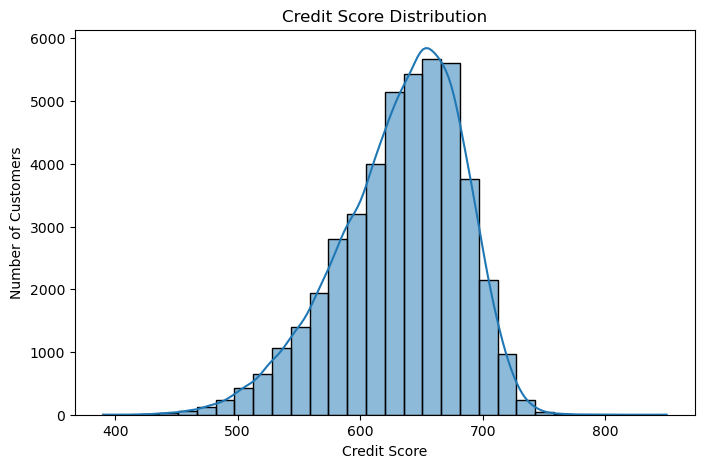

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['credit_score'], bins=30, kde=True)
plt.title('Credit Score Distribution')
plt.xlabel('Credit Score')
plt.ylabel('Number of Customers')
plt.show()

In [24]:
df.groupby('loan_status')['credit_score'].mean()

loan_status
0    632.814914
1    631.887200
Name: credit_score, dtype: float64

#### The average credit score is almost similar for both default and non-default customers. Credit score alone may not be enough to predict loan default risk in this dataset.

### Income Analysis

In [25]:
df['person_income'].describe()

count    4.500000e+04
mean     8.031905e+04
std      8.042250e+04
min      8.000000e+03
25%      4.720400e+04
50%      6.704800e+04
75%      9.578925e+04
max      7.200766e+06
Name: person_income, dtype: float64

### The average customer income is around 80K. The difference between mean and median income indicates the presence of high-income outliers in the dataset.

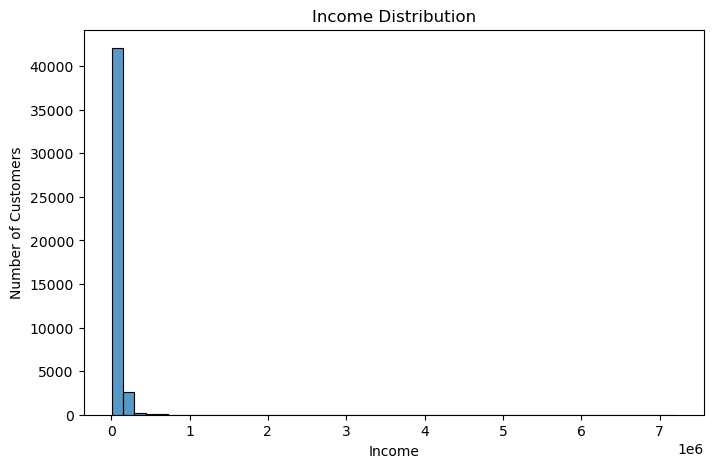

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(df['person_income'], bins=50)
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Number of Customers')
plt.show()

In [27]:
df.groupby('loan_status')['person_income'].mean()

loan_status
0    86157.040743
1    59886.096900
Name: person_income, dtype: float64

#### Customers who defaulted have lower average income compared to customers who did not default. Lower income levels may increase loan repayment risk.

### Loan Amount Analysis

In [28]:
df['loan_amnt'].describe()

count    45000.000000
mean      9583.157556
std       6314.886691
min        500.000000
25%       5000.000000
50%       8000.000000
75%      12237.250000
max      35000.000000
Name: loan_amnt, dtype: float64

#### The average loan amount is around 9.5K. Most customers have loan amounts closer to the median value of 8K, while some customers have higher loan amounts.

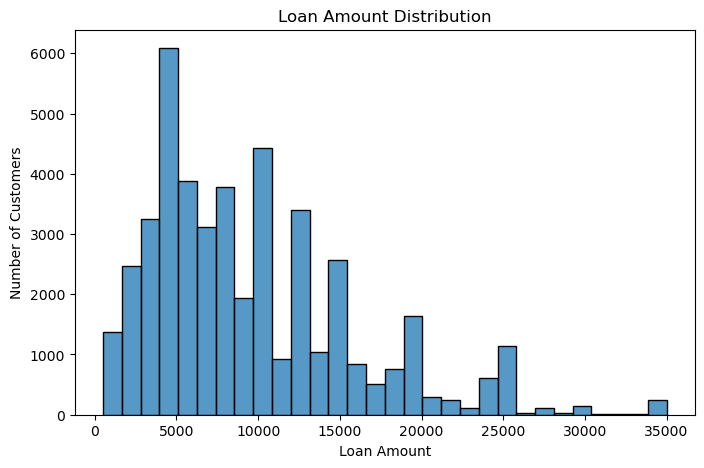

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(df['loan_amnt'], bins=30)
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.ylabel('Number of Customers')
plt.show()

In [30]:
df.groupby('loan_status')['loan_amnt'].mean()

loan_status
0     9219.576914
1    10855.689800
Name: loan_amnt, dtype: float64

#### Customers who defaulted have a higher average loan amount compared to non-default customers. Larger loan amounts may contribute to higher repayment risk.

### Loan Purpose Analysis

In [31]:
df['loan_intent'].value_counts()

loan_intent
EDUCATION            9153
MEDICAL              8548
VENTURE              7819
PERSONAL             7552
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: count, dtype: int64

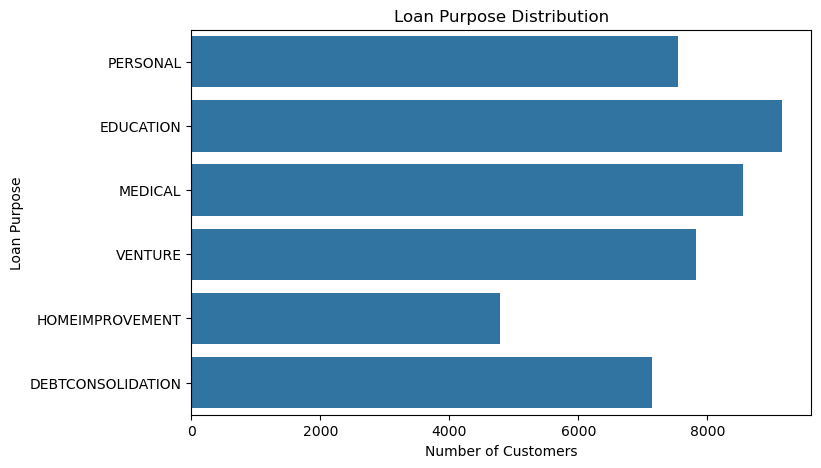

In [32]:
plt.figure(figsize=(8,5))
sns.countplot(
    y='loan_intent',
    data=df)
plt.title('Loan Purpose Distribution')
plt.xlabel('Number of Customers')
plt.ylabel('Loan Purpose')
plt.show()

In [35]:
loan_purpose_risk = df.groupby('loan_intent')['loan_status'].mean()*100
loan_purpose_risk
loan_purpose_risk.sort_values(ascending=False)

loan_intent
DEBTCONSOLIDATION    30.272918
MEDICAL              27.819373
HOMEIMPROVEMENT      26.301484
PERSONAL             20.140360
EDUCATION            16.956189
VENTURE              14.426397
Name: loan_status, dtype: float64

#### Debt consolidation loans show the highest default rate, followed by medical and home improvement loans. Venture and education loans have comparatively lower default rates.

### Customer Profile Analysis

In [37]:
gender_risk = df.groupby('person_gender')['loan_status'].mean()*100
gender_risk

person_gender
female    22.248127
male      22.201200
Name: loan_status, dtype: float64

#### Default rates are almost similar for both male and female customers. Gender does not show a significant impact on loan default risk in this dataset.

### Education Risk Analysis

In [38]:
education_risk = df.groupby('person_education')['loan_status'].mean()*100
education_risk.sort_values(ascending=False)

person_education
Doctorate      22.866345
Bachelor       22.524069
High School    22.310391
Associate      22.031926
Master         21.762178
Name: loan_status, dtype: float64

#### Default rates are almost similar across different education levels. Education does not appear to be a strong factor affecting loan default risk in this dataset.

### Home Ownership Risk

In [39]:
home_risk = df.groupby('person_home_ownership')['loan_status'].mean()*100
home_risk.sort_values(ascending=False)

person_home_ownership
OTHER       33.333333
RENT        32.397731
MORTGAGE    11.596084
OWN          7.522874
Name: loan_status, dtype: float64

#### Customers with rented or other home ownership categories show higher default rates compared to customers who own homes or have mortgages. Home ownership may be an important factor in assessing loan risk.

### Previous Loan Default Analysis

In [40]:
previous_default_risk = df.groupby('previous_loan_defaults_on_file')['loan_status'].mean()*100
previous_default_risk

previous_loan_defaults_on_file
No     45.163039
Yes     0.000000
Name: loan_status, dtype: float64

#### Previous loan default history shows an unexpected pattern in this dataset. Customers without previous defaults have a higher observed default rate, while customers with previous defaults show 0% default rate. This may require further investigation of the data distribution.

In [41]:
df['previous_loan_defaults_on_file'].value_counts()

previous_loan_defaults_on_file
Yes    22858
No     22142
Name: count, dtype: int64

#### Previous loan default history shows an unexpected pattern. Customers marked as having previous loan defaults show a 0% current default rate, while customers without previous defaults show a higher default rate. This may indicate a specific data definition or encoding pattern in this dataset and requires further investigation.

### Interest Rate Analysis

In [42]:
df['loan_int_rate'].describe()

count    45000.000000
mean        11.006606
std          2.978808
min          5.420000
25%          8.590000
50%         11.010000
75%         12.990000
max         20.000000
Name: loan_int_rate, dtype: float64

#### The average loan interest rate is around 11%. Interest rates vary from 5.42% to 20%, showing different risk levels assigned to customers.

In [43]:
df.groupby('loan_status')['loan_int_rate'].mean()

loan_status
0    10.477981
1    12.856794
Name: loan_int_rate, dtype: float64

#### Customers who defaulted have a higher average interest rate compared to non-default customers. Higher interest rates may contribute to increased repayment risk.

### Loan Burden Analysis

In [44]:
df['loan_burden'] = df['loan_amnt'] / df['person_income']
df['loan_burden'].head()

0    0.486462
1    0.081420
2    0.442193
3    0.438855
4    0.529221
Name: loan_burden, dtype: float64

#### Loan burden was calculated by comparing loan amount with customer income. Higher loan burden values indicate customers with greater repayment pressure.

In [45]:
df.groupby('loan_status')['loan_burden'].mean()

loan_status
0    0.121810
1    0.202532
Name: loan_burden, dtype: float64

#### Customers who defaulted have a higher average loan burden compared to non-default customers. Higher loan burden indicates increased financial pressure and may contribute to higher default risk.

### Feature Engineering

In [46]:
df['loan_burden_category'] = pd.cut(
    df['loan_burden'],
    bins=[0, 0.1, 0.3, 1],
    labels=['Low', 'Medium', 'High'])
df['loan_burden_category'].value_counts()

loan_burden_category
Medium    24703
Low       17694
High       2603
Name: count, dtype: int64

#### Most customers fall under the Medium loan burden category. A smaller group of customers have High loan burden, which indicates higher repayment pressure.

In [47]:
burden_risk = df.groupby('loan_burden_category', observed=False)['loan_status'].mean()*100
burden_risk.sort_values(ascending=False)

loan_burden_category
High      72.531694
Medium    24.426183
Low       11.744094
Name: loan_status, dtype: float64

#### Customers with High loan burden have the highest default rate of 72.53%. As loan burden increases, default risk also increases significantly. Loan burden is an important factor for assessing customer risk.

In [48]:
df['credit_score_category'] = pd.cut(
    df['credit_score'],
    bins=[0, 580, 670, 850],
    labels=['Poor', 'Average', 'Good'])
df['credit_score_category'].value_counts()

credit_score_category
Average    26992
Good       10934
Poor        7074
Name: count, dtype: int64

#### Most customers belong to the Average credit score category. A smaller number of customers have Poor credit scores, which may represent higher-risk borrowers.

In [49]:
credit_risk = df.groupby('credit_score_category', observed=False)['loan_status'].mean()*100
credit_risk.sort_values(ascending=False)

credit_score_category
Average    22.451097
Poor       22.307040
Good       21.602341
Name: loan_status, dtype: float64

#### Default rates are almost similar across Poor, Average, and Good credit score categories. Credit score alone does not appear to be a strong predictor of loan default risk in this dataset.

In [50]:
df['income_category'] = pd.cut(
    df['person_income'],
    bins=[0, 40000, 80000, 200000, float('inf')],
    labels=['Low', 'Medium', 'High', 'Very High'])
df['income_category'].value_counts()

income_category
Medium       21223
High         15169
Low           7365
Very High     1243
Name: count, dtype: int64

#### Most customers belong to the Medium income category, followed by High income customers. Very High income customers represent a smaller portion of the dataset.

In [51]:
income_risk = df.groupby('income_category', observed=False)['loan_status'].mean()*100
income_risk.sort_values(ascending=False)

income_category
Low          45.838425
Medium       22.178768
High         11.826752
Very High     9.895414
Name: loan_status, dtype: float64

#### Low income customers show the highest default rate of 45.84%. As income increases, the default rate decreases, indicating that income level is an important factor in loan risk assessment.

In [52]:
df['age_category'] = pd.cut(
    df['person_age'],
    bins=[0, 25, 40, 60, 100],
    labels=['Young', 'Adult', 'Middle Age', 'Senior'])
df['age_category'].value_counts()

age_category
Adult         22720
Young         20441
Middle Age     1761
Senior           71
Name: count, dtype: int64

#### Most customers belong to the Adult and Young age categories. Senior customers represent a very small portion of the dataset, so age-based conclusions for this group should be interpreted carefully.

In [53]:
age_risk = df.groupby('age_category', observed=False)['loan_status'].mean()*100
age_risk.sort_values(ascending=False)

age_category
Senior        25.352113
Young         23.394159
Middle Age    21.408291
Adult         21.227993
Name: loan_status, dtype: float64

#### Age categories show small differences in default rates. Senior customers have a higher default rate, but their sample size is very small. Young customers show slightly higher risk compared to other larger age groups.

### Correlation Analysis

In [54]:
corr = df.select_dtypes(include='number').corr()
corr

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,loan_burden
person_age,1.000000,0.193698,0.954412,0.050750,0.013402,-0.043299,0.861985,0.178432,-0.021476,-0.043487
person_income,0.193698,1.000000,0.185987,0.242290,0.001510,-0.234177,0.124316,0.035919,-0.135808,-0.234133
person_emp_exp,0.954412,0.185987,1.000000,0.044589,0.016631,-0.039862,0.824272,0.186196,-0.020481,-0.040050
loan_amnt,0.050750,0.242290,0.044589,1.000000,0.146093,0.593011,0.042969,0.009074,0.107714,0.593309
loan_int_rate,0.013402,0.001510,0.016631,0.146093,1.000000,0.125209,0.018008,0.011498,0.332005,0.125687
loan_percent_income,-0.043299,-0.234177,-0.039862,0.593011,0.125209,1.000000,-0.031868,-0.011483,0.384880,0.999446
cb_person_cred_hist_length,0.861985,0.124316,0.824272,0.042969,0.018008,-0.031868,1.000000,0.155204,-0.014851,-0.032095
credit_score,0.178432,0.035919,0.186196,0.009074,0.011498,-0.011483,0.155204,1.000000,-0.007647,-0.011425
loan_status,-0.021476,-0.135808,-0.020481,0.107714,0.332005,0.384880,-0.014851,-0.007647,1.000000,0.385011
loan_burden,-0.043487,-0.234133,-0.040050,0.593309,0.125687,0.999446,-0.032095,-0.011425,0.385011,1.000000


#### Correlation analysis shows that loan burden, loan percent income, and interest rate have the strongest positive relationship with loan default. Higher financial burden and higher interest rates are associated with increased default risk. Credit score shows very weak correlation with default in this dataset.

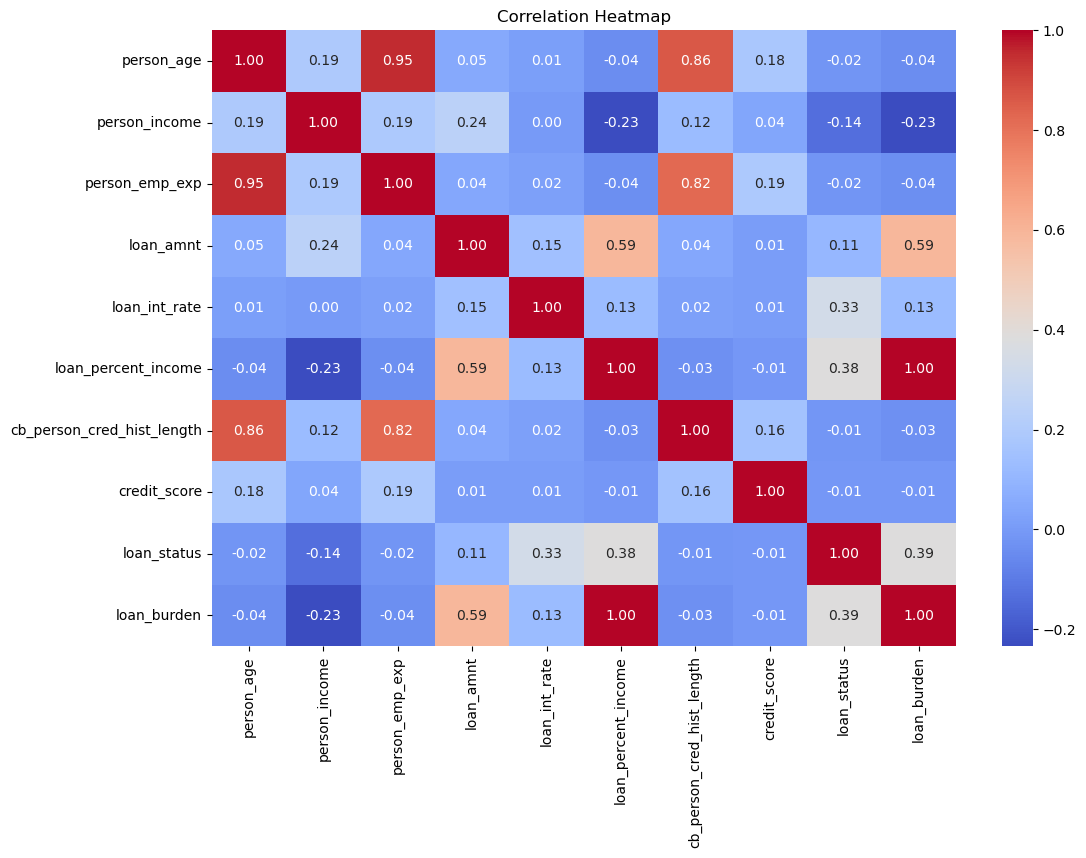

In [55]:
plt.figure(figsize=(12,8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## Final Project Insights

### Key Findings:

- Around 22% of customers have defaulted on loans.
- Loan burden is one of the strongest factors affecting default risk.
- Customers with high loan burden show significantly higher default rates.
- Low income customers have higher default risk compared to high income customers.
- Debt consolidation loans show the highest default rate among loan purposes.
- Higher interest rates are associated with increased default risk.
- Credit score shows limited impact on default prediction in this dataset.

In [59]:
df.to_csv(r"C:\Users\soumy\Downloads\bank_loan_risk_final.csv", index=False)